# ЛР3: сравнение Flash Attention в Google Colab на CUDA GPU

Перед запуском включи GPU: `Runtime` -> `Change runtime type` -> `T4 GPU` / `L4 GPU` / `A100 GPU`. Ноутбук специально падает с ошибкой, если CUDA недоступна, чтобы случайно не получить результаты на CPU или локальном MPS.

## 1. Загрузка проекта

Если проект уже загружен в `/content/modern-ai-architecture`, ячейка переключает его на ветку `lab3` и обновляет ее. Иначе она клонирует с GitHub сразу ветку `lab3`.

In [1]:
from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/BogdanRoshchupkin/modern-ai-architecture.git"
BRANCH = "lab3"
REPO_DIR = Path("/content/modern-ai-architecture")

if not (REPO_DIR / "src/backend/flash_attention.py").exists():
    if REPO_DIR.exists():
        raise RuntimeError(f"{REPO_DIR} exists, but src/backend/flash_attention.py was not found")
    subprocess.run(["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)], check=True)
else:
    os.chdir(REPO_DIR)
    subprocess.run(["git", "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "checkout", BRANCH], check=True)
    subprocess.run(["git", "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
active_branch = subprocess.check_output(["git", "branch", "--show-current"], text=True).strip()
print("Working directory:", Path.cwd())
print("Active branch:", active_branch)
assert active_branch == BRANCH, f"Expected branch {BRANCH}, got {active_branch}"

Working directory: /content/modern-ai-architecture
Active branch: lab3


## 2. Минимальные зависимости

PyTorch в Colab уже установлен с CUDA. Здесь ставятся только пакеты для тестов, таблицы и графика.

In [2]:
import sys
import subprocess

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest", "pandas", "matplotlib"], check=True)
print("Dependencies are ready")

Dependencies are ready


## 3. Проверка, что используется именно CUDA

In [3]:
import subprocess
import torch

try:
    print(subprocess.check_output(["nvidia-smi"], text=True))
except Exception as exc:
    print("nvidia-smi is not available:", exc)

print("torch:", torch.__version__)
print("torch CUDA build:", torch.version.cuda)
assert torch.cuda.is_available(), "CUDA is not available. In Colab choose Runtime -> Change runtime type -> GPU, then rerun."

device = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
print("Selected device:", torch.cuda.get_device_name(0))
print("MPS ignored; this notebook uses CUDA only.")

Fri Jun 12 21:13:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. Smoke-test корректности на GPU

Проверяем, что блочный forward совпадает с reference-реализацией PyTorch на CUDA.

In [4]:
import torch

from src.backend.flash_attention import masked_flash_attention_forward, torch_masked_attention

torch.manual_seed(0)
q = torch.randn(2, 4, 96, 64, device=device, dtype=torch.float16)
k = torch.randn_like(q)
v = torch.randn_like(q)
segment_ids = torch.ones(2, 96, device=device, dtype=torch.long)
segment_ids[:, 72:] = 2
segment_ids[:, -8:] = 0

with torch.no_grad():
    expected = torch_masked_attention(q, k, v, segment_ids)
    actual = masked_flash_attention_forward(q, k, v, segment_ids, block_m=32, block_n=32)

max_abs_error = (actual.float() - expected.float()).abs().max().item()
torch.testing.assert_close(actual.float(), expected.float(), atol=2e-2, rtol=2e-2)
print(f"GPU correctness smoke-test passed. max_abs_error={max_abs_error:.6f}")

GPU correctness smoke-test passed. max_abs_error=0.001953


## 5. Benchmark: torch reference vs blocked Flash Attention

Колонки `torch_ms` и `flash_ms` сравнивают время. Колонки памяти сравнивают размер полной score-матрицы `[batch, heads, seq_len, seq_len]` против одного score-блока `[batch, heads, block_m, block_n]`. Для этой учебной реализации главный выигрыш ожидается по памяти; реальное ускорение по времени обычно требует CUDA/Triton kernel без Python-циклов.

In [5]:
import pandas as pd

from src.backend.flash_attention import benchmark_flash_attention

configs = [
    {"batch_size": 2, "n_heads": 4, "seq_len": 256, "head_dim": 64, "block_m": 64, "block_n": 64, "repeats": 20},
    {"batch_size": 2, "n_heads": 4, "seq_len": 512, "head_dim": 64, "block_m": 64, "block_n": 64, "repeats": 10},
    {"batch_size": 2, "n_heads": 4, "seq_len": 1024, "head_dim": 64, "block_m": 64, "block_n": 64, "repeats": 5},
]

rows = []
for cfg in configs:
    torch.cuda.empty_cache()
    result = benchmark_flash_attention(device="cuda", **cfg)
    row = dict(cfg)
    row.update(
        torch_ms=result.torch_ms,
        flash_ms=result.flash_ms,
        speedup=result.speedup,
        torch_score_memory_mb=result.torch_score_memory_mb,
        flash_score_memory_mb=result.flash_score_memory_mb,
        score_memory_reduction=result.memory_ratio,
    )
    rows.append(row)

df = pd.DataFrame(rows)
display(df.style.format({
    "torch_ms": "{:.3f}",
    "flash_ms": "{:.3f}",
    "speedup": "{:.2f}x",
    "torch_score_memory_mb": "{:.2f}",
    "flash_score_memory_mb": "{:.2f}",
    "score_memory_reduction": "{:.2f}x",
}))

,batch_size,n_heads,seq_len,head_dim,block_m,block_n,repeats,torch_ms,flash_ms,speedup,torch_score_memory_mb,flash_score_memory_mb,score_memory_reduction
0,2,4,256,64,64,64,20,0.420,8.472,0.05x,1.00,0.06,16.00x
1,2,4,512,64,64,64,10,0.596,29.247,0.02x,4.00,0.06,64.00x
2,2,4,1024,64,64,64,5,1.889,114.378,0.02x,16.00,0.06,256.00x


## 6. Графики

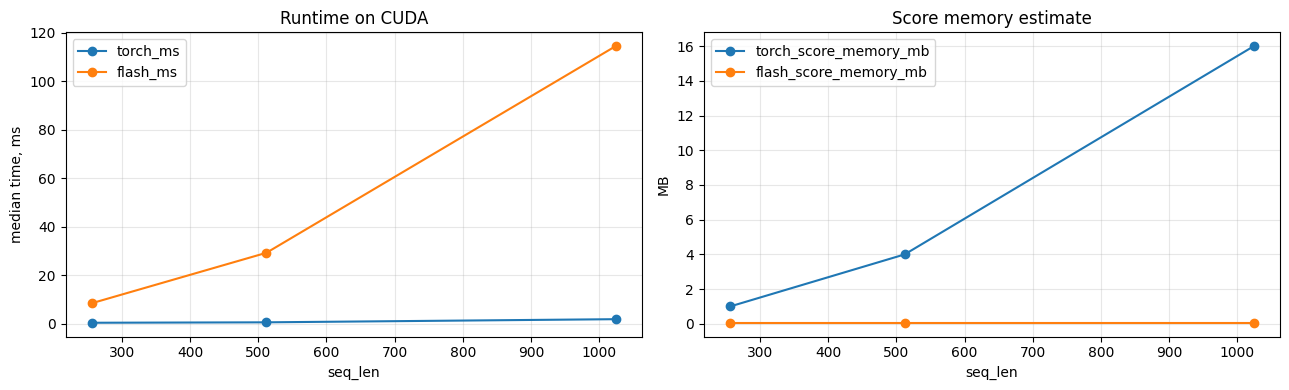

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.plot(x="seq_len", y=["torch_ms", "flash_ms"], marker="o", ax=axes[0])
axes[0].set_title("Runtime on CUDA")
axes[0].set_xlabel("seq_len")
axes[0].set_ylabel("median time, ms")
axes[0].grid(True, alpha=0.3)

df.plot(x="seq_len", y=["torch_score_memory_mb", "flash_score_memory_mb"], marker="o", ax=axes[1])
axes[1].set_title("Score memory estimate")
axes[1].set_xlabel("seq_len")
axes[1].set_ylabel("MB")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Один запуск через CLI

Эта ячейка нужна, если в отчете хочется показать ровно такой же формат, как в `README.md`, но с `--device cuda`.

In [7]:
!python -m cli.lab3 --device cuda --seq-len 512 --head-dim 64 --heads 4 --batch-size 2 --repeats 10

torch attention median: 0.716 ms
flash attention median: 30.179 ms
speedup: 0.02x
torch score matrix memory: 4.00 MB
flash score block memory: 0.06 MB
score-memory reduction: 64.00x
